In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
data = pd.read_csv('cs_07.csv')

In [4]:
data.head()

,order_id,created_ts,shamsy_date,customer_id,total_purchase
0,5c92a3d9a7b11b0001e4ec46,3/21/2019 0:04,1398-Farvardin-1,5bf1092b24aa9a000135ac7c,240000.0
1,5c92af8024aa9a00015b536d,3/21/2019 0:54,1398-Farvardin-1,58d2fe9b46e0fb0001e432c0,620000.0
2,5c930b0ea7b11b0001e4f07e,3/21/2019 7:24,1398-Farvardin-1,5c85f140a7b11b0001e65ec1,320000.0
3,5c93157324aa9a00015b5750,3/21/2019 8:09,1398-Farvardin-1,59c52fe152faff00014e4932,220000.0
4,5c93250024aa9a00015b5884,3/21/2019 9:15,1398-Farvardin-1,58eba26fd601800001b98a34,360000.0


In [5]:
data.shape

(40537, 5)

# Data Understanding - Phase 1

### 1: Understand data collection process

### Data gathered from an Iranian e-commerce database over a 4-month period (from Farvardin 1398 to Tir 1398)

### 2: Document data set description (meta data)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40537 entries, 0 to 40536
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        40537 non-null  object 
 1   created_ts      40537 non-null  object 
 2   shamsy_date     40537 non-null  object 
 3   customer_id     40537 non-null  object 
 4   total_purchase  40537 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.5+ MB


##### 0 order_id: order idification

##### 1 created_ts: time of execution of customer's order

##### 2 shamsy_date: date of execution of customer's order based on Persian calendar

##### 3 customer_id: customer identification

##### 4 total_purchase: amount of purchase in Rials

### 3: missing values

In [11]:
data.isnull().sum()

order_id          0
created_ts        0
shamsy_date       0
customer_id       0
total_purchase    0
date              0
dtype: int64

## Data Preparation

In [7]:
#Convert created_ts to datetime
data['created_ts'] = pd.to_datetime(data['created_ts'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40537 entries, 0 to 40536
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        40537 non-null  object        
 1   created_ts      40537 non-null  datetime64[ns]
 2   shamsy_date     40537 non-null  object        
 3   customer_id     40537 non-null  object        
 4   total_purchase  40537 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 1.5+ MB


In [8]:
data.iloc[:, 1]

0       2019-03-21 00:04:00
1       2019-03-21 00:54:00
2       2019-03-21 07:24:00
3       2019-03-21 08:09:00
4       2019-03-21 09:15:00
                ...        
40532   2019-07-22 22:44:00
40533   2019-07-22 22:49:00
40534   2019-07-22 22:53:00
40535   2019-07-22 23:16:00
40536   2019-07-22 23:44:00
Name: created_ts, Length: 40537, dtype: datetime64[ns]

In [9]:
#Extract date from datetime
data['created_ts'].dt.date

0        2019-03-21
1        2019-03-21
2        2019-03-21
3        2019-03-21
4        2019-03-21
            ...    
40532    2019-07-22
40533    2019-07-22
40534    2019-07-22
40535    2019-07-22
40536    2019-07-22
Name: created_ts, Length: 40537, dtype: object

In [10]:
#Extract date from datetime and save in date column
data['date'] = pd.to_datetime(data['created_ts'].dt.date)
data.head()

,order_id,created_ts,shamsy_date,customer_id,total_purchase,date
0,5c92a3d9a7b11b0001e4ec46,2019-03-21 00:04:00,1398-Farvardin-1,5bf1092b24aa9a000135ac7c,240000.0,2019-03-21
1,5c92af8024aa9a00015b536d,2019-03-21 00:54:00,1398-Farvardin-1,58d2fe9b46e0fb0001e432c0,620000.0,2019-03-21
2,5c930b0ea7b11b0001e4f07e,2019-03-21 07:24:00,1398-Farvardin-1,5c85f140a7b11b0001e65ec1,320000.0,2019-03-21
3,5c93157324aa9a00015b5750,2019-03-21 08:09:00,1398-Farvardin-1,59c52fe152faff00014e4932,220000.0,2019-03-21
4,5c93250024aa9a00015b5884,2019-03-21 09:15:00,1398-Farvardin-1,58eba26fd601800001b98a34,360000.0,2019-03-21


## Create Features based on RFM Approach

In [12]:
data['date']

0       2019-03-21
1       2019-03-21
2       2019-03-21
3       2019-03-21
4       2019-03-21
           ...    
40532   2019-07-22
40533   2019-07-22
40534   2019-07-22
40535   2019-07-22
40536   2019-07-22
Name: date, Length: 40537, dtype: datetime64[ns]

In [13]:
#Calculate recency for each transaction
recency = pd.to_datetime('2019-07-23') - data['date']
recency

0       124 days
1       124 days
2       124 days
3       124 days
4       124 days
          ...   
40532     1 days
40533     1 days
40534     1 days
40535     1 days
40536     1 days
Name: date, Length: 40537, dtype: timedelta64[ns]

In [14]:
#Extract the absolute number from timedelta
recency.dt.days

0        124
1        124
2        124
3        124
4        124
        ... 
40532      1
40533      1
40534      1
40535      1
40536      1
Name: date, Length: 40537, dtype: int64

In [15]:
#Extract the absolute number from timedelta and save in recency column
data['recency'] = recency.dt.days
data.head()

,order_id,created_ts,shamsy_date,customer_id,total_purchase,date,recency
0,5c92a3d9a7b11b0001e4ec46,2019-03-21 00:04:00,1398-Farvardin-1,5bf1092b24aa9a000135ac7c,240000.0,2019-03-21,124
1,5c92af8024aa9a00015b536d,2019-03-21 00:54:00,1398-Farvardin-1,58d2fe9b46e0fb0001e432c0,620000.0,2019-03-21,124
2,5c930b0ea7b11b0001e4f07e,2019-03-21 07:24:00,1398-Farvardin-1,5c85f140a7b11b0001e65ec1,320000.0,2019-03-21,124
3,5c93157324aa9a00015b5750,2019-03-21 08:09:00,1398-Farvardin-1,59c52fe152faff00014e4932,220000.0,2019-03-21,124
4,5c93250024aa9a00015b5884,2019-03-21 09:15:00,1398-Farvardin-1,58eba26fd601800001b98a34,360000.0,2019-03-21,124


In [16]:
#Calculate recency for each customer
customer_r = pd.DataFrame({'recency': data.groupby(by = ['customer_id'])['recency'].min()})
customer_r.head()

,recency
customer_id,
5.94687E+23,9
5.94772E+23,64
5.94773E+23,9
5.95E+25,5
58a4b0e452faff000179dbd0,7


### Frequency

In [17]:
#Calculate frequency for each customer
customer_f = pd.DataFrame({'frequency': data.groupby(by = ['customer_id'])['order_id'].count()})
customer_f.head()

,frequency
customer_id,
5.94687E+23,2
5.94772E+23,1
5.94773E+23,5
5.95E+25,1
58a4b0e452faff000179dbd0,7


### Monetary

In [18]:
#Calculate monetary for each customer
customer_m = pd.DataFrame({'monetary': data.groupby(by = ['customer_id'])['total_purchase'].sum()})
customer_m.head()

,monetary
customer_id,
5.94687E+23,680000.0
5.94772E+23,600000.0
5.94773E+23,1700000.0
5.95E+25,320000.0
58a4b0e452faff000179dbd0,1480000.0


### RFM Dataframe

In [19]:
df = customer_f.merge(customer_r, left_index = True, right_index = True)
df.head()

,frequency,recency
customer_id,,
5.94687E+23,2,9
5.94772E+23,1,64
5.94773E+23,5,9
5.95E+25,1,5
58a4b0e452faff000179dbd0,7,7


In [20]:
rfm = df.merge(customer_m, left_index = True, right_index = True)
rfm.head()

,frequency,recency,monetary
customer_id,,,
5.94687E+23,2,9,680000.0
5.94772E+23,1,64,600000.0
5.94773E+23,5,9,1700000.0
5.95E+25,1,5,320000.0
58a4b0e452faff000179dbd0,7,7,1480000.0


In [21]:
rfm.shape

(14964, 3)

In [22]:
%whos

Variable               Type         Data/Info
---------------------------------------------
customer_f             DataFrame    Shape: (14964, 1)
customer_m             DataFrame    Shape: (14964, 1)
customer_r             DataFrame    Shape: (14964, 1)
data                   DataFrame    Shape: (40537, 7)
dataframe_columns      function     <function dataframe_columns at 0x16b3b3e20>
dataframe_hash         function     <function dataframe_hash at 0x16b3b3c40>
df                     DataFrame    Shape: (14964, 2)
dtypes_str             function     <function dtypes_str at 0x16b3b25c0>
get_dataframes         function     <function get_dataframes at 0x16b3b18a0>
getpass                module       <module 'getpass' from '/<...>b/python3.13/getpass.py'>
hashlib                module       <module 'hashlib' from '/<...>b/python3.13/hashlib.py'>
import_pandas_safely   function     <function import_pandas_safely at 0x16b3b3ec0>
is_data_frame          function     <function is_data_frame at 0

In [24]:
#Remove some dataframes to free RAM
del(customer_f, customer_m, customer_r, data, df)

NameError: name 'customer_f' is not defined

In [25]:
del(recency)

# Data Understanding - Phase 2

### 4: Univariate data analysis

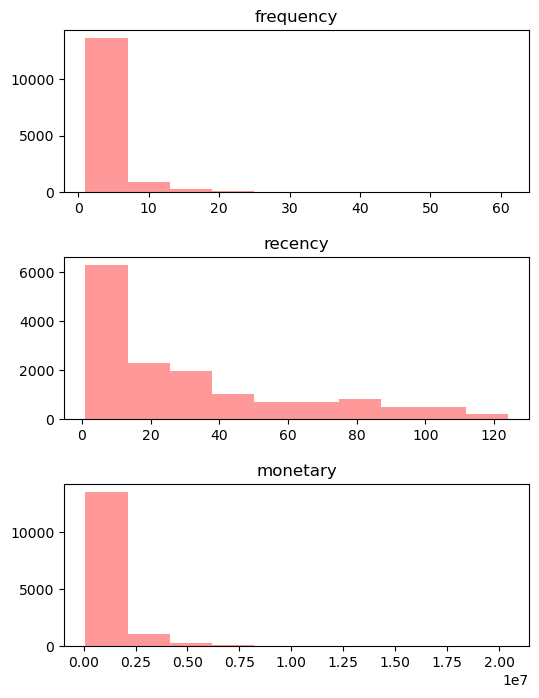

In [26]:
#Histogram of numeric variables
plt.figure(figsize = (6, 8))
plt.subplots_adjust(hspace = 0.4, wspace = 0.4)
for i in range(1, 4):
    plt.subplot(3, 1, i)
    plt.hist(x = rfm.iloc[: , i - 1], alpha = 0.4, color = 'red')
    plt.title(rfm.columns[i - 1])

In [27]:
#Summary statistics of numeric variables
rfm.describe()

,frequency,recency,monetary
count,14964.000000,14964.000000,1.496400e+04
mean,2.708968,30.497995,9.448944e+05
std,3.425412,30.833106,1.217563e+06
min,1.000000,1.000000,8.000000e+04
25%,1.000000,7.000000,3.200000e+05
50%,1.000000,19.000000,5.200000e+05
75%,3.000000,43.000000,1.040000e+06
max,61.000000,124.000000,2.042000e+07


### 5: Bivariate data analysis

In [28]:
#Correlation analysis
corr_table = round(rfm.corr(method = 'pearson'), 2)
corr_table
#Note: high colinearity btw frequency and monetary
#Decision: remove monetary as a feature

,frequency,recency,monetary
frequency,1.00,-0.26,0.95
recency,-0.26,1.00,-0.26
monetary,0.95,-0.26,1.00


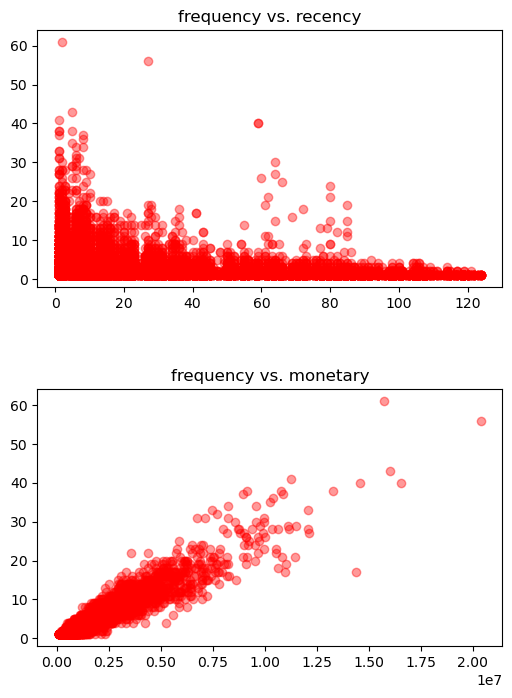

In [29]:
#Scatterplot of numeric variables
plt.figure(figsize = (6, 8))
plt.subplots_adjust(hspace = 0.4, wspace = 0.4)
for i in range(1, 3):
    plt.subplot(2, 1, i)
    plt.scatter(x = rfm.iloc[: , i], y = rfm['frequency'], alpha = 0.4, color = 'red')
    plt.title('frequency vs. ' + rfm.columns[i])

# Build Clustering Models

In [30]:
#Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rf_scaled = scaler.fit_transform(rfm.loc[:, ['frequency', 'recency']])
rf_scaled

array([[-0.20698004, -0.69726072],
       [-0.49892549,  1.08659584],
       [ 0.66885632, -0.69726072],
       ...,
       [-0.49892549, -0.95673077],
       [-0.49892549, -0.95673077],
       [-0.49892549, -0.95673077]], shape=(14964, 2))

### Hierarchical Clustering

In [31]:
#Hierarchical clustering with average linkage
from sklearn.cluster import AgglomerativeClustering
hclust = AgglomerativeClustering(distance_threshold = None,
                                 linkage = 'average',
                                 n_clusters = 5)
model_1 = hclust.fit(rf_scaled)

In [32]:
#Save cluster labels for each customer
rfm['hclust_ave_link'] = model_1.labels_
rfm.head()

,frequency,recency,monetary,hclust_ave_link
customer_id,,,,
5.94687E+23,2,9,680000.0,1
5.94772E+23,1,64,600000.0,1
5.94773E+23,5,9,1700000.0,1
5.95E+25,1,5,320000.0,1
58a4b0e452faff000179dbd0,7,7,1480000.0,1


In [33]:
#Check if there is missing value in cluster labels
np.sum(rfm['hclust_ave_link'].isnull())

np.int64(0)

In [34]:
#Function to calculate total within cluster sum of squares
def twcss(data, model):
    #data is np.array, model is from sklearn cluerting algorithm class
    #A list to save within-cluster sum of squares
    wcss = []
    #For loop over clusters
    for i in np.unique(model.labels_):
        #Calculate center of each cluster
        center = np.mean(data[np.where(model.labels_ == i)], axis = 0)
        #Calculate within-cluster sum of squares for each cluster
        wcss.append(np.sum(np.sum((data[np.where(model.labels_ == i)] - center) ** 2, axis = 1)))
    return sum(wcss)

In [35]:
#Model evaluation - model 1
from sklearn.metrics import silhouette_score

models_comp = pd.DataFrame({'TWCSS': twcss(rf_scaled, model_1),
                            'Ave Silhouette Score': silhouette_score(rf_scaled, model_1.labels_)},
                           index = ['Hierarchical Clustering - Average Linkage'])
models_comp

,TWCSS,Ave Silhouette Score
Hierarchical Clustering - Average Linkage,18704.823571,0.592739


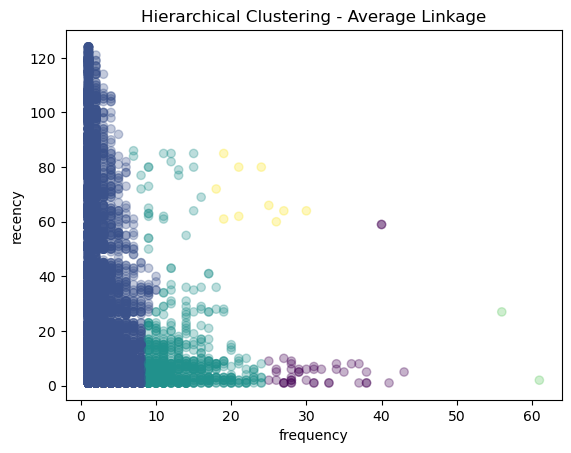

In [36]:
#Scatter Plot - model 1
plt.scatter(x = rfm['frequency'], 
            y = rfm['recency'], 
            c = rfm['hclust_ave_link'], alpha = 0.3)
plt.xlabel('frequency')
plt.ylabel('recency')
plt.title('Hierarchical Clustering - Average Linkage')
plt.show()

In [37]:
#Hierarchical clustering with Ward's linkage
from sklearn.cluster import AgglomerativeClustering
hclust = AgglomerativeClustering(distance_threshold = None,
                                 linkage = 'ward',
                                 n_clusters = 5)
model_2 = hclust.fit(rf_scaled)

In [38]:
#Save cluster labels for each customer
rfm['hclust_ward_link'] = model_2.labels_
rfm.head()

,frequency,recency,monetary,hclust_ave_link,hclust_ward_link
customer_id,,,,,
5.94687E+23,2,9,680000.0,1,1
5.94772E+23,1,64,600000.0,1,2
5.94773E+23,5,9,1700000.0,1,4
5.95E+25,1,5,320000.0,1,1
58a4b0e452faff000179dbd0,7,7,1480000.0,1,4


In [39]:
#Check if there is missing value in cluster labels
np.sum(rfm['hclust_ward_link'].isnull())

np.int64(0)

In [40]:
#Model evaluation - model 2
from sklearn.metrics import silhouette_score

models_comp = pd.concat([models_comp,
                         pd.DataFrame({'TWCSS': twcss(rf_scaled, model_2),
                                       'Ave Silhouette Score': silhouette_score(rf_scaled, model_2.labels_)},
                                      index = ['Hierarchical Clustering - Ward Linkage'])])
models_comp

,TWCSS,Ave Silhouette Score
Hierarchical Clustering - Average Linkage,18704.823571,0.592739
Hierarchical Clustering - Ward Linkage,5096.982759,0.476442


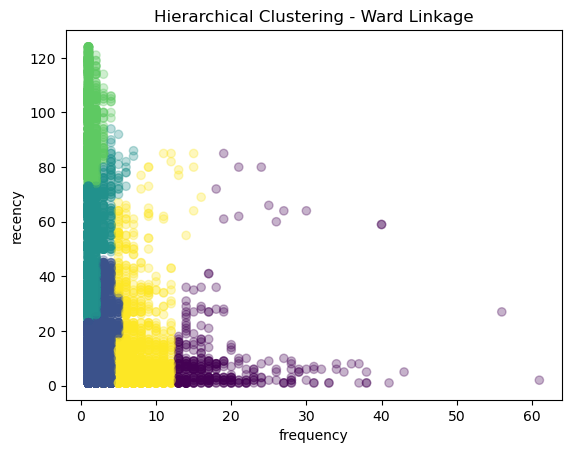

In [41]:
#Scatter Plot - model 2
plt.scatter(x = rfm['frequency'], 
            y = rfm['recency'], 
            c = rfm['hclust_ward_link'], alpha = 0.3)
plt.xlabel('frequency')
plt.ylabel('recency')
plt.title('Hierarchical Clustering - Ward Linkage')
plt.show()

### k-means Clustering

In [42]:
#kmeans clustering
from sklearn.cluster import KMeans

import os
os.environ['OMP_NUM_THREADS'] = '4'

kmclust = KMeans(n_clusters = 5, 
                 init = 'k-means++', 
                 n_init = 10)
model_3 = kmclust.fit(rf_scaled)

In [43]:
#Save cluster labels for each customer
rfm['kmeans'] = model_3.labels_
rfm.head()

,frequency,recency,monetary,hclust_ave_link,hclust_ward_link,kmeans
customer_id,,,,,,
5.94687E+23,2,9,680000.0,1,1,0
5.94772E+23,1,64,600000.0,1,2,1
5.94773E+23,5,9,1700000.0,1,4,3
5.95E+25,1,5,320000.0,1,1,0
58a4b0e452faff000179dbd0,7,7,1480000.0,1,4,3


In [44]:
#Check if there is missing value in cluster labels
np.sum(rfm['kmeans'].isnull())

np.int64(0)

In [45]:
#Model evaluation - model 3
from sklearn.metrics import silhouette_score

models_comp = pd.concat([models_comp,
                         pd.DataFrame({'TWCSS': twcss(rf_scaled, model_3),
                                       'Ave Silhouette Score': silhouette_score(rf_scaled, model_3.labels_)},
                                      index = ['kmeans'])])
models_comp

,TWCSS,Ave Silhouette Score
Hierarchical Clustering - Average Linkage,18704.823571,0.592739
Hierarchical Clustering - Ward Linkage,5096.982759,0.476442
kmeans,4670.715394,0.499200


In [46]:
print(model_3.inertia_)
print(twcss(rf_scaled, model_3))

4670.715393919226
4670.715393919241


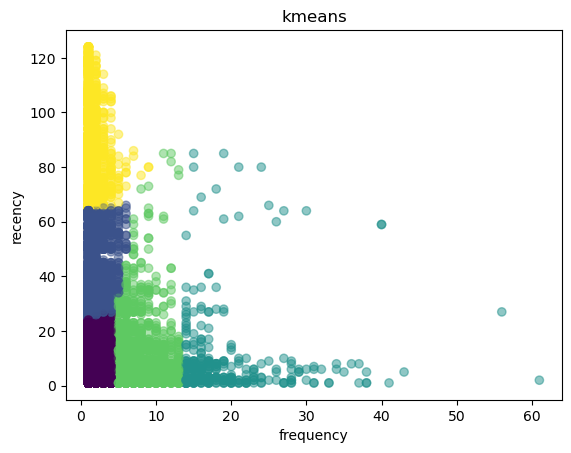

In [47]:
#Scatter Plot - model 3
plt.scatter(x = rfm['frequency'], 
            y = rfm['recency'], 
            c = rfm['kmeans'], alpha = 0.5)
plt.xlabel('frequency')
plt.ylabel('recency')
plt.title('kmeans')
plt.show()

## Optimal Number of Clusters

### Elbow Method

In [48]:
#Calculate TWCSS for different number of clusters
twcss_scores = []
for k in range(1, 11):
    kmclust = KMeans(n_clusters = k, 
                     init = 'k-means++', 
                     n_init = 10)
    model = kmclust.fit(rf_scaled)
    twcss_scores.append(twcss(rf_scaled, model))

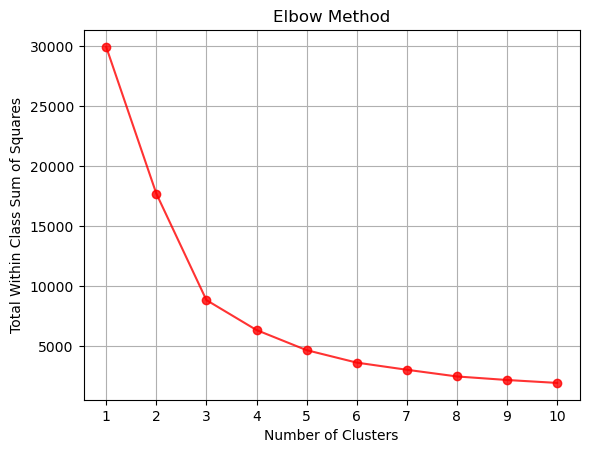

In [49]:
#Elbow method
plt.plot(range(1, 11), twcss_scores, 'r-o', alpha = 0.8)
plt.grid()    
plt.xticks(range(1, 11))
plt.xlabel('Number of Clusters')
plt.ylabel('Total Within Class Sum of Squares')
plt.title('Elbow Method')
plt.show()

### Average Silhouette Method

In [50]:
#Calculate average silhouette scores for different number of clusters
from sklearn.metrics import silhouette_score
ave_silhouette_scores = []
for k in range(2, 11):
    kmclust = KMeans(n_clusters = k, 
                     init = 'k-means++', 
                     n_init = 10)
    model = kmclust.fit(rf_scaled)
    score = silhouette_score(rf_scaled, model.labels_)
    ave_silhouette_scores.append(score)

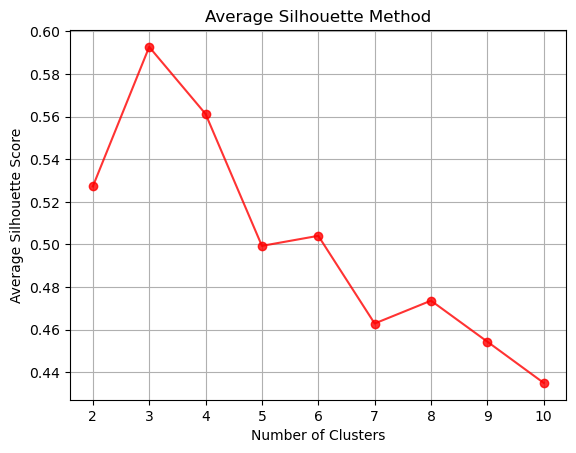

In [51]:
#Average Silhouette Method
plt.plot(range(2, 11), ave_silhouette_scores, 'r-o', alpha = 0.8)
plt.grid()    
plt.xticks(range(2, 11))
plt.xlabel('Number of Clusters')
plt.ylabel('Average Silhouette Score')
plt.title('Average Silhouette Method')
plt.show()

### Cluster Analysis from Marketing Perspective

In [52]:
#Cluster analysis based on average RFM score
df = rfm.groupby('kmeans')[['frequency', 'recency', 'monetary']].mean()
df

,frequency,recency,monetary
kmeans,,,
0,1.833882,9.707273,6.540527e+05
1,1.556010,40.378305,5.475988e+05
2,19.317308,10.339744,6.512821e+06
3,7.409015,10.050640,2.575548e+06
4,1.291134,88.687300,4.391454e+05


In [53]:
#Calculate cluster size and revenue share
df['pop_size'] = rfm.groupby('kmeans')['frequency'].count()
df['pop_share'] = np.round(df['pop_size'] / np.sum(df['pop_size']) * 100, 1)
df['revenue_share'] = np.round(rfm.groupby('kmeans')['monetary'].sum() / np.sum(rfm['monetary']) * 100, 1)
df

,frequency,recency,monetary,pop_size,pop_share,revenue_share
kmeans,,,,,,
0,1.833882,9.707273,6.540527e+05,6682,44.7,30.9
1,1.556010,40.378305,5.475988e+05,3669,24.5,14.2
2,19.317308,10.339744,6.512821e+06,312,2.1,14.4
3,7.409015,10.050640,2.575548e+06,1797,12.0,32.7
4,1.291134,88.687300,4.391454e+05,2504,16.7,7.8
